# Telecom X Challenge — Predicción de cancelación de clientes

Este notebook organiza el flujo completo del challenge para identificar los factores asociados a la **evasión/cancelación de clientes** y comparar el desempeño de dos modelos de clasificación:

- **Regresión Logística**
- **Random Forest**

> Nota metodológica: en esta versión se usa `class_weight='balanced'` para tratar el desbalance de clases.  
> **SMOTE no se aplica** dentro del flujo principal para evitar *data leakage* y mantener una evaluación limpia sobre el conjunto de prueba.

## 1. Objetivo del análisis

1. Preparar y transformar los datos para modelado.
2. Explorar las variables más relacionadas con la cancelación.
3. Entrenar y comparar dos modelos de clasificación.
4. Identificar factores que influyen en la evasión.
5. Proponer acciones de retención basadas en los hallazgos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Carga de datos

Ajusta la ruta según el entorno donde ejecutes el notebook.

In [2]:
DATA_PATH = '/content/datos_TelecomX_part1.csv'  # Cambiar si el archivo está en otra ruta
datos = pd.read_csv(DATA_PATH)

print(f"Filas: {datos.shape[0]} | Columnas: {datos.shape[1]}")
datos.head()

Filas: 7043 | Columnas: 22


,ID_Cliente,Evasion,Genero,Adulto_Mayor,Pareja,Dependientes,Antiguedad,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,Seguridad_Online,Backup_Online,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Contrato,Factura_Electronica,Metodo_Pago,Cargo_Mensual,Cargo_Total,Valor_Diario
0,0002-ORFBO,0.0,Femenino,0,1,1,9,1,0,DSL,0,1,0,1,1,0,Anual,1,Cheque por correo,65.6,593.30,2.186667
1,0003-MKNFE,0.0,Masculino,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Mensual,0,Cheque por correo,59.9,542.40,1.996667
2,0004-TLHLJ,1.0,Masculino,0,0,0,4,1,0,Fibra óptica,0,0,1,0,0,0,Mensual,1,Cheque electrónico,73.9,280.85,2.463333
3,0011-IGKFF,1.0,Masculino,1,1,0,13,1,0,Fibra óptica,0,1,1,0,1,1,Mensual,1,Cheque electrónico,98.0,1237.85,3.266667
4,0013-EXCHZ,1.0,Femenino,1,1,0,3,1,0,Fibra óptica,0,0,0,1,1,0,Mensual,1,Cheque por correo,83.9,267.40,2.796667


In [3]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_Cliente              7043 non-null   object 
 1   Evasion                 7043 non-null   float64
 2   Genero                  7043 non-null   object 
 3   Adulto_Mayor            7043 non-null   int64  
 4   Pareja                  7043 non-null   int64  
 5   Dependientes            7043 non-null   int64  
 6   Antiguedad              7043 non-null   int64  
 7   Servicio_Telefonico     7043 non-null   int64  
 8   Multiples_Lineas        7043 non-null   int64  
 9   Servicio_Internet       7043 non-null   object 
 10  Seguridad_Online        7043 non-null   int64  
 11  Backup_Online           7043 non-null   int64  
 12  Proteccion_Dispositivo  7043 non-null   int64  
 13  Soporte_Tecnico         7043 non-null   int64  
 14  Streaming_TV            7043 non-null   

## 3. Limpieza y selección de variables

Se eliminan variables que no aportan capacidad predictiva directa al modelo:

- `ID_Cliente`: identificador único
- `Valor_Diario`: variable redundante frente a `Cargo_Mensual`
- `Genero`: descartada según el análisis previo por bajo aporte al problema

In [4]:
columnas_a_eliminar = ['ID_Cliente', 'Valor_Diario', 'Genero']
datos_clean = datos.drop(columns=columnas_a_eliminar)

print(f"Dimensión después de limpieza: {datos_clean.shape}")
datos_clean.head()

Dimensión después de limpieza: (7043, 19)


,Evasion,Adulto_Mayor,Pareja,Dependientes,Antiguedad,Servicio_Telefonico,Multiples_Lineas,Servicio_Internet,Seguridad_Online,Backup_Online,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Contrato,Factura_Electronica,Metodo_Pago,Cargo_Mensual,Cargo_Total
0,0.0,0,1,1,9,1,0,DSL,0,1,0,1,1,0,Anual,1,Cheque por correo,65.6,593.30
1,0.0,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Mensual,0,Cheque por correo,59.9,542.40
2,1.0,0,0,0,4,1,0,Fibra óptica,0,0,1,0,0,0,Mensual,1,Cheque electrónico,73.9,280.85
3,1.0,1,1,0,13,1,0,Fibra óptica,0,1,1,0,1,1,Mensual,1,Cheque electrónico,98.0,1237.85
4,1.0,1,1,0,3,1,0,Fibra óptica,0,0,0,1,1,0,Mensual,1,Cheque por correo,83.9,267.40


## 4. Codificación de variables categóricas

Se utiliza **One-Hot Encoding** para convertir variables categóricas a formato numérico.

In [5]:
cols_categoricas = datos_clean.select_dtypes(include=['object']).columns.tolist()
cols_categoricas

['Servicio_Internet', 'Contrato', 'Metodo_Pago']

In [6]:
datos_ml = pd.get_dummies(datos_clean, columns=cols_categoricas, drop_first=True)

print(f"Dimensión del dataset modelable: {datos_ml.shape}")
datos_ml.head()

Dimensión del dataset modelable: (7043, 23)


,Evasion,Adulto_Mayor,Pareja,Dependientes,Antiguedad,Servicio_Telefonico,Multiples_Lineas,Seguridad_Online,Backup_Online,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Factura_Electronica,Cargo_Mensual,Cargo_Total,Servicio_Internet_Fibra óptica,Servicio_Internet_No,Contrato_Bianual,Contrato_Mensual,Metodo_Pago_Cheque por correo,Metodo_Pago_Tarjeta de crédito,Metodo_Pago_Transferencia bancaria
0,0.0,0,1,1,9,1,0,0,1,0,1,1,0,1,65.6,593.30,False,False,False,False,True,False,False
1,0.0,0,0,0,9,1,1,0,0,0,0,0,1,0,59.9,542.40,False,False,False,True,True,False,False
2,1.0,0,0,0,4,1,0,0,0,1,0,0,0,1,73.9,280.85,True,False,False,True,False,False,False
3,1.0,1,1,0,13,1,0,0,1,1,0,1,1,1,98.0,1237.85,True,False,False,True,False,False,False
4,1.0,1,1,0,3,1,0,0,0,0,1,1,0,1,83.9,267.40,True,False,False,True,True,False,False


## 5. Verificación del desbalance de clases

Este paso permite observar si la variable objetivo está desbalanceada.

In [7]:
proporcion = datos_ml['Evasion'].value_counts(normalize=True).mul(100).round(2)
conteo = datos_ml['Evasion'].value_counts()

display(pd.DataFrame({
    'conteo': conteo,
    'porcentaje': proporcion
}))

,conteo,porcentaje
Evasion,,
0.0,5174,73.46
1.0,1869,26.54


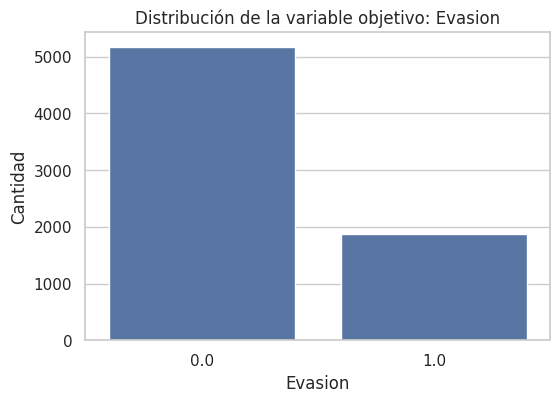

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(data=datos_ml, x='Evasion')
plt.title('Distribución de la variable objetivo: Evasion')
plt.xlabel('Evasion')
plt.ylabel('Cantidad')
plt.show()

## 6. Escalado de variables numéricas

Se estandarizan variables numéricas continuas para favorecer especialmente el desempeño de la **Regresión Logística**.

In [9]:
cols_a_escalar = ['Antiguedad', 'Cargo_Mensual', 'Cargo_Total']

datos_ml_scaled = datos_ml.copy()
scaler = StandardScaler()
datos_ml_scaled[cols_a_escalar] = scaler.fit_transform(datos_ml_scaled[cols_a_escalar])

datos_ml_scaled[cols_a_escalar].describe().T

,count,mean,std,min,25%,50%,75%,max
Antiguedad,7043.0,-2.824818e-17,1.000071,-1.318165,-0.951682,-0.137274,0.921455,1.613701
Cargo_Mensual,7043.0,-6.658501e-17,1.000071,-1.545860,-0.972540,0.185733,0.833833,1.794352
Cargo_Total,7043.0,-1.452764e-16,1.000071,-0.997542,-0.829998,-0.390568,0.664794,2.825857


## 7. Análisis de correlación

Se calcula la correlación con `Evasion` para identificar señales preliminares sobre variables asociadas a la cancelación.

In [10]:
corr_matrix = datos_ml_scaled.corr()
correlacion_evasion = corr_matrix['Evasion'].sort_values(ascending=False)

correlacion_evasion.head(15)

,Evasion
Evasion,1.000000
Contrato_Mensual,0.405103
Servicio_Internet_Fibra óptica,0.308020
Cargo_Mensual,0.193356
Factura_Electronica,0.191825
Adulto_Mayor,0.150889
Multiples_Lineas,0.019423
Servicio_Telefonico,0.011942
Metodo_Pago_Cheque por correo,-0.091683
Metodo_Pago_Transferencia bancaria,-0.117937


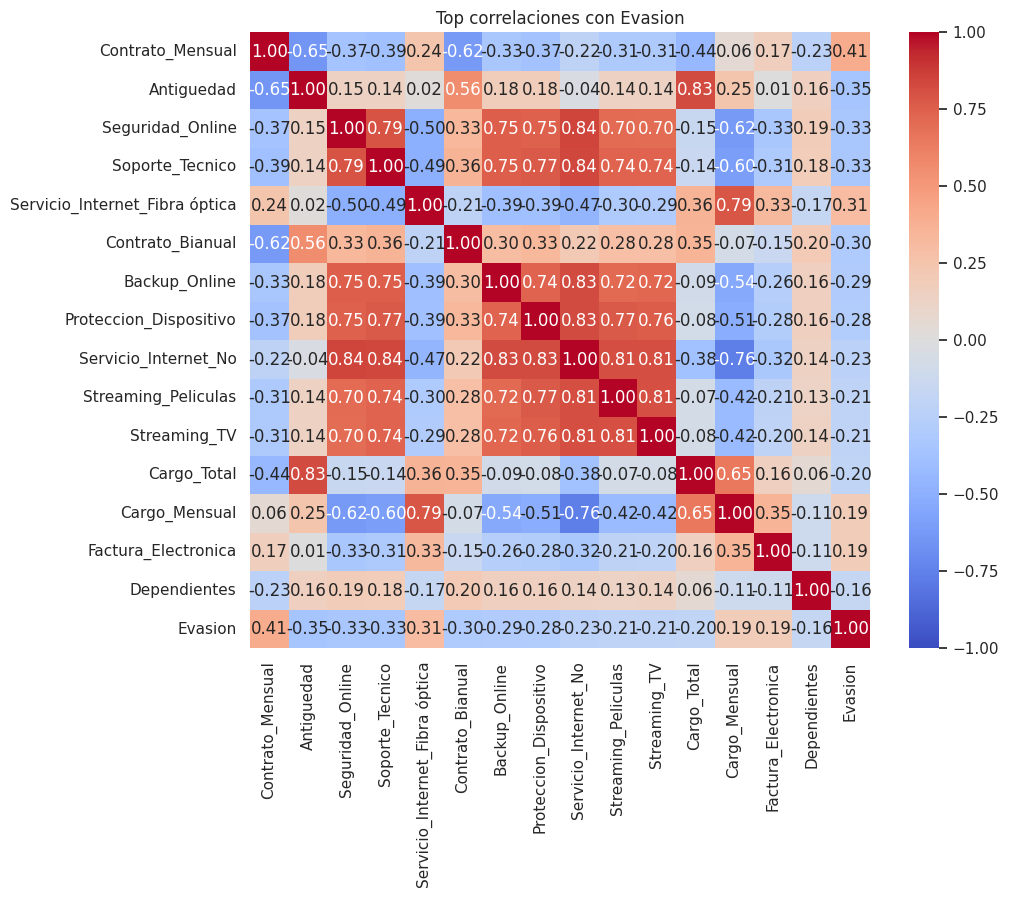

In [11]:
plt.figure(figsize=(10, 8))
top_corr = correlacion_evasion.drop('Evasion').abs().sort_values(ascending=False).head(15).index.tolist() + ['Evasion']
sns.heatmap(datos_ml_scaled[top_corr].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Top correlaciones con Evasion')
plt.show()

## 8. Visualización dirigida de variables relevantes

Se incluyen visualizaciones simples para apoyar la presentación de hallazgos.

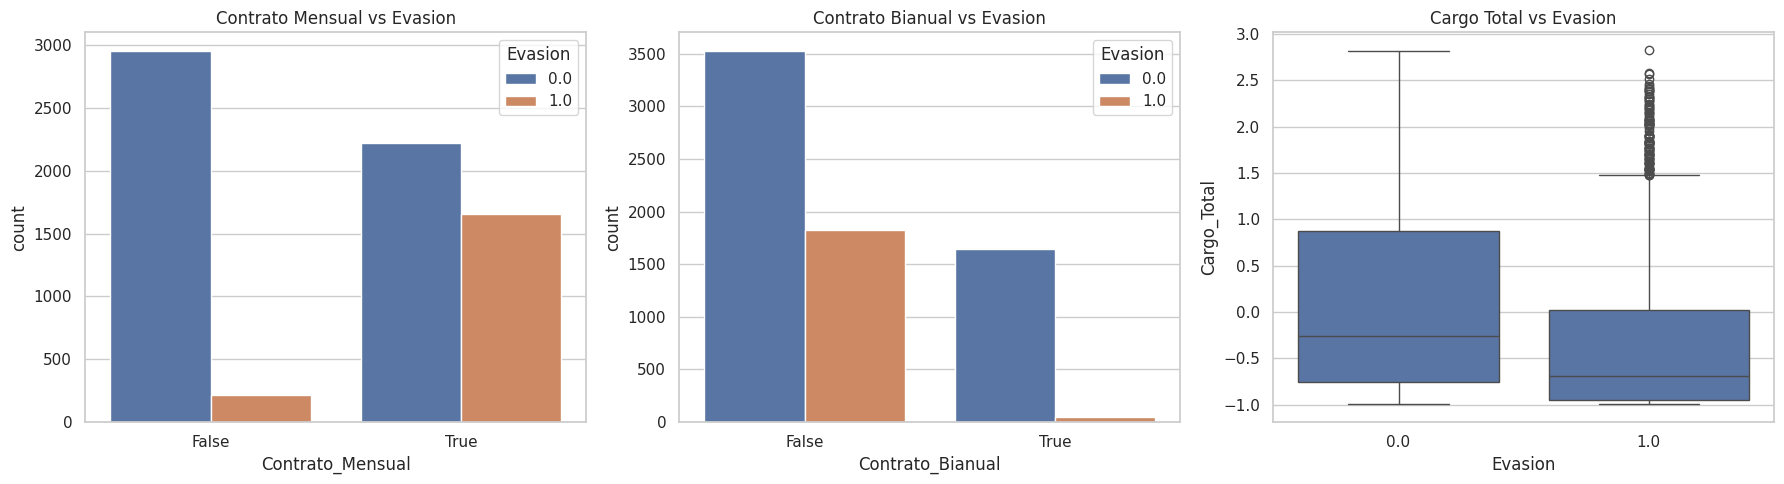

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=datos_ml_scaled, x='Contrato_Mensual', hue='Evasion', ax=axes[0])
axes[0].set_title('Contrato Mensual vs Evasion')

sns.countplot(data=datos_ml_scaled, x='Contrato_Bianual', hue='Evasion', ax=axes[1])
axes[1].set_title('Contrato Bianual vs Evasion')

sns.boxplot(data=datos_ml_scaled, x='Evasion', y='Cargo_Total', ax=axes[2])
axes[2].set_title('Cargo Total vs Evasion')

plt.tight_layout()
plt.show()

## 9. Separación entre entrenamiento y prueba

Se utiliza partición estratificada para conservar la proporción de clases en ambos conjuntos.

In [13]:
X = datos_ml_scaled.drop(columns=['Evasion'])
y = datos_ml_scaled['Evasion']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Tamaño entrenamiento:", X_train.shape, y_train.shape)
print("Tamaño prueba:", X_test.shape, y_test.shape)

Tamaño entrenamiento: (5634, 22) (5634,)
Tamaño prueba: (1409, 22) (1409,)


## 10. Entrenamiento de modelos

Se usan pesos balanceados (`class_weight='balanced'`) para compensar el desbalance de clases sin alterar el conjunto de prueba.

In [14]:
modelo_lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
modelo_rf = RandomForestClassifier(class_weight='balanced', random_state=42)

modelo_lr.fit(X_train, y_train)
modelo_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

## 11. Evaluación de desempeño

In [15]:
pred_lr = modelo_lr.predict(X_test)
pred_rf = modelo_rf.predict(X_test)

print("=== Regresión Logística ===")
print(classification_report(y_test, pred_lr))

print("=== Random Forest ===")
print(classification_report(y_test, pred_rf))

=== Regresión Logística ===
              precision    recall  f1-score   support

         0.0       0.90      0.72      0.80      1035
         1.0       0.50      0.79      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

=== Random Forest ===
              precision    recall  f1-score   support

         0.0       0.82      0.90      0.86      1035
         1.0       0.62      0.46      0.52       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



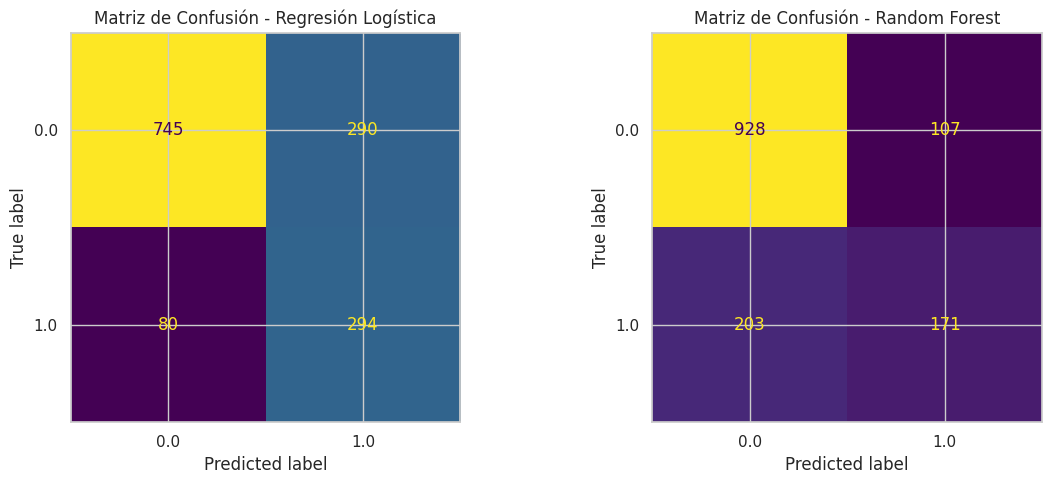

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, pred_lr, ax=axes[0], colorbar=False)
axes[0].set_title('Matriz de Confusión - Regresión Logística')

ConfusionMatrixDisplay.from_predictions(y_test, pred_rf, ax=axes[1], colorbar=False)
axes[1].set_title('Matriz de Confusión - Random Forest')

plt.tight_layout()
plt.show()

In [17]:
reporte_lr = classification_report(y_test, pred_lr, output_dict=True)
reporte_rf = classification_report(y_test, pred_rf, output_dict=True)

comparacion = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision (Clase 1)', 'Recall (Clase 1)', 'F1-score (Clase 1)'],
    'Regresión Logística': [
        reporte_lr['accuracy'],
        reporte_lr['1.0']['precision'],
        reporte_lr['1.0']['recall'],
        reporte_lr['1.0']['f1-score']
    ],
    'Random Forest': [
        reporte_rf['accuracy'],
        reporte_rf['1.0']['precision'],
        reporte_rf['1.0']['recall'],
        reporte_rf['1.0']['f1-score']
    ]
})

comparacion

,Métrica,Regresión Logística,Random Forest
0,Accuracy,0.737402,0.779986
1,Precision (Clase 1),0.503425,0.615108
2,Recall (Clase 1),0.786096,0.457219
3,F1-score (Clase 1),0.613779,0.524540


## 12. Factores más influyentes

Para interpretar mejor los resultados:
- En **Regresión Logística**, se analizan los coeficientes absolutos.
- En **Random Forest**, se analizan las importancias de variables.

In [18]:
coef_lr = pd.DataFrame({
    'variable': X.columns,
    'coeficiente': modelo_lr.coef_[0],
    'abs_coef': np.abs(modelo_lr.coef_[0])
}).sort_values('abs_coef', ascending=False)

coef_lr.head(10)

,variable,coeficiente,abs_coef
3,Antiguedad,-1.294121,1.294121
15,Servicio_Internet_Fibra óptica,0.814299,0.814299
17,Contrato_Bianual,-0.709259,0.709259
18,Contrato_Mensual,0.703983,0.703983
14,Cargo_Total,0.618592,0.618592
21,Metodo_Pago_Transferencia bancaria,-0.418279,0.418279
19,Metodo_Pago_Cheque por correo,-0.407247,0.407247
20,Metodo_Pago_Tarjeta de crédito,-0.385603,0.385603
9,Soporte_Tecnico,-0.382938,0.382938
12,Factura_Electronica,0.343367,0.343367


In [19]:
imp_rf = pd.DataFrame({
    'variable': X.columns,
    'importancia': modelo_rf.feature_importances_
}).sort_values('importancia', ascending=False)

imp_rf.head(10)

,variable,importancia
14,Cargo_Total,0.175969
13,Cargo_Mensual,0.158601
3,Antiguedad,0.158067
18,Contrato_Mensual,0.083750
17,Contrato_Bianual,0.043241
9,Soporte_Tecnico,0.041896
6,Seguridad_Online,0.039103
15,Servicio_Internet_Fibra óptica,0.037489
7,Backup_Online,0.027907
10,Streaming_TV,0.024692


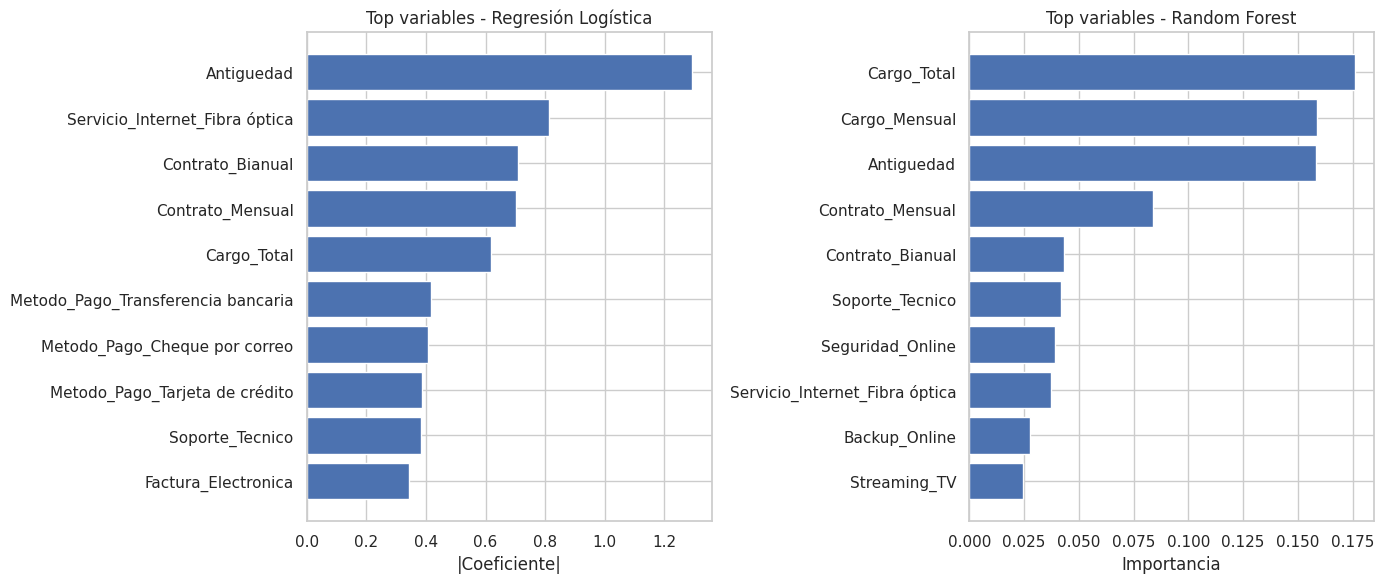

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_lr = coef_lr.head(10).sort_values('abs_coef')
axes[0].barh(top_lr['variable'], top_lr['abs_coef'])
axes[0].set_title('Top variables - Regresión Logística')
axes[0].set_xlabel('|Coeficiente|')

top_rf = imp_rf.head(10).sort_values('importancia')
axes[1].barh(top_rf['variable'], top_rf['importancia'])
axes[1].set_title('Top variables - Random Forest')
axes[1].set_xlabel('Importancia')

plt.tight_layout()
plt.show()

## 13. Conclusiones

### Comparación general
- **Random Forest** obtuvo mejor *accuracy* general.
- **Regresión Logística** detectó mejor la clase positiva en términos de *recall*.

### Lectura de negocio
Los factores más relacionados con la evasión suelen concentrarse en variables como:
- tipo de contrato,
- antigüedad,
- cargos mensuales o totales,
- forma de pago,
- y servicios asociados.

### Recomendaciones
- fortalecer la retención en clientes nuevos,
- incentivar contratos de mayor permanencia,
- ofrecer beneficios a clientes con alto riesgo de evasión,
- revisar clientes con cargos altos o baja vinculación con servicios.